Import Packages

In [ ]:
from IPython import get_ipython
from IPython.display import display
# %% [markdown]
# Import Packages
# %%
!pip install opencv-python
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action="ignore")


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, accuracy_score


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import TensorBoard,EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import cv2
# %% [markdown]
# Construct Filepath image to dataframe with image classes
# %%

Construct Filepath image to dataframe with image classes

In [ ]:
bengin_path = r"/content/Bengin"
malignant_early_pre_b = r"/content/[Malignant] early Pre-B"
malignat_pre_b = r"/content/[Malignant] Pre-B"
melignant_pro_b = r"/content/[Malignant] Pro-B"

img_classes = ["Bengin cases", "Malignant Early cases", "Malignant Pre_B Cases", "Malignant Pro_B cases"]
path_list = [bengin_path, malignant_early_pre_b, malignat_pre_b, melignant_pro_b]

img_path = []
class_labels = []
for i, dir_list in enumerate(path_list):
    name_img = os.listdir(dir_list)
    for name_file in name_img:
        img = os.path.join(dir_list,name_file)
        img_path.append(img)
        class_labels.append(img_classes[i])

df = pd.DataFrame({"img_path" : img_path,
                  "label" : class_labels})

df.head()

,img_path,label
0,/content/Bengin/Snap_020 (2).jpg,Bengin cases
1,/content/Bengin/Snap_099 (3).jpg,Bengin cases
2,/content/Bengin/Snap_023.jpg,Bengin cases
3,/content/Bengin/Snap_033.jpg,Bengin cases
4,/content/Bengin/Snap_007 (3).jpg,Bengin cases


Visualization Image

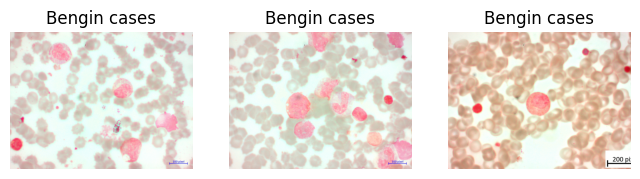

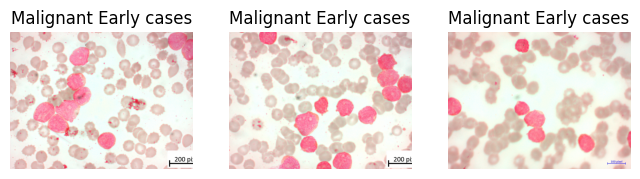

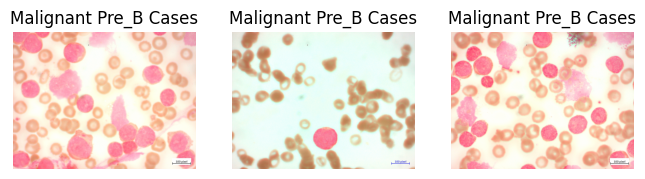

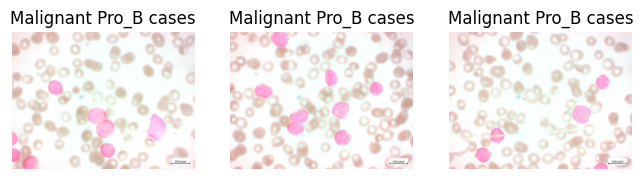

In [ ]:
for category, group in df.groupby("label"):
    fig, ax = plt.subplots(1,3, figsize = (8,8))
    ax = ax.ravel()
    for i, (_,r) in enumerate(group.sample(3).iterrows()):
        img = cv2.imread(r.img_path)
        ax[i].imshow(img)
        ax[i].axis("off")
        ax[i].set_title(r.label)
    plt.show()

Exploratory Data Analysis

In [ ]:
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

In [ ]:
!pip install plotly
import plotly.express as px

countData = df["label"].value_counts().reset_index()
fig = px.histogram(data_frame = countData, x = "label", y = "count")
fig.show()

Extract Image Properties (Size, Resolution, Color Distribution)

In [ ]:
sizes = []
resolutions = []
color_distributions = []

for img_path in df["img_path"]:
    #load image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    #Get image size
    size = os.path.getsize(img_path)
    sizes.append(size)
    #Extract the resolution of images
    resolution = img.shape[:2]
    resolutions.append(resolution)
    #Extract color distribution
    mean_color_distributions = np.bincount(img.flatten(), minlength = 256)
    color_distributions.append(mean_color_distributions)
sizes = np.array(sizes)
resolutions = np.array(resolutions)
color_distributions = np.array(color_distributions)

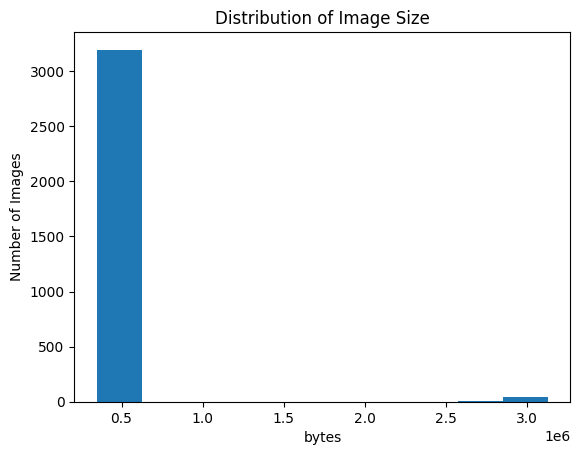

In [ ]:
plt.hist(sizes)
plt.title("Distribution of Image Size")
plt.xlabel("bytes")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
sizes_MB = []
for img_path in df["img_path"]:

    img = cv2.imread(img_path)

    size = os.path.getsize(img_path)
    sizes_MB.append(size/1_000_000)

fig = px.histogram(x=sizes_MB, nbins = 50, title = "Distribution of Image Sizes")
fig.update_layout(xaxis_title = "File Size (MB)",
                 yaxis_title = "Number of Images",
                 showlegend = False,
                 bargap = 0.1,
                 bargroupgap = 0.1)
fig.update_traces(marker = dict(color = "green"))
fig.show()

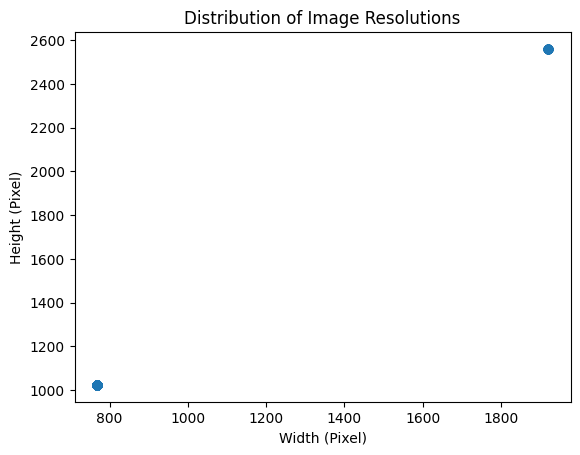

In [ ]:
plt.scatter(resolutions[:,0], resolutions[:,1])
plt.title("Distribution of Image Resolutions")
plt.ylabel("Height (Pixel)")
plt.xlabel("Width (Pixel)")
plt.show()

In [ ]:
fig = px.scatter(x = resolutions[:,0], y = resolutions[:,1], title = "Distribution of Image Resolution")
fig.update_layout(
    xaxis_title = "Width (Pixel)",
    yaxis_title = "Height (Pixel)",
    showlegend = False,
    hovermode = "closest"
)
fig.update_traces(marker = dict(color="red"))
fig.show()

In [ ]:
import plotly.graph_objects as go
mean_color_distributions = np.mean(color_distributions, axis = 0)
fig = go.Figure(
    go.Bar(x = np.arange(256), y = mean_color_distributions, name = "Mean Color Distributions"
))
fig.update_layout(
    title = "Mean Color Distribution",
    xaxis_title = "Color Values",
    yaxis_title = "Number of Pixel"
)
fig.show()

Train Test Split

In [ ]:
train_ratio = 0.70
test_ratio = 0.15
val_ratio = 0.15

df_train, df_test_val = train_test_split(df, train_size = train_ratio, random_state = 42)
df_test, df_val = train_test_split(df_test_val, train_size = test_ratio/(test_ratio+val_ratio), random_state = 42)

print(f"Train shape = {df_train.shape}")
print(f"Test shape = {df_test.shape}")
print(f"Validation shape = {df_val.shape}")

Train shape = (2269, 2)
Test shape = (486, 2)
Validation shape = (487, 2)


Create Denoise Function using Median Blur

In [ ]:
def preprocessing_denoise(img):
    denoise_img = cv2.medianBlur(img, 1)
    denoise_img = cv2.cvtColor(denoise_img, cv2.COLOR_BGR2RGB)
    return denoise_img

Image Data Generator

In [ ]:
IMG_WIDTH = 224
IMG_HEIGHT = 224

image_size = (IMG_WIDTH, IMG_HEIGHT)
batch_size = 32

TRAIN_DATAGEN = ImageDataGenerator(rescale = 1./255.,
                                   preprocessing_function = preprocessing_denoise,
                                  rotation_range = 30,
                                  width_shift_range = 0.1,
                                  height_shift_range = 0.2,
                                  shear_range = 0.1,
                                  zoom_range = 0.2,
                                  horizontal_flip = True)

TEST_DATAGEN = ImageDataGenerator(rescale = 1./255.)

train_generator = TRAIN_DATAGEN.flow_from_dataframe(
    df_train,
    x_col = "img_path",
    y_col = "label",
    target_size = image_size,
    batch_size = batch_size,
    color_mode = "rgb",
    class_mode = "categorical",
    shuffle = True
)

val_generator = TEST_DATAGEN.flow_from_dataframe(
    df_val,
    x_col = "img_path",
    y_col = "label",
    target_size = image_size,
    batch_size = batch_size,
    color_mode = "rgb",
    class_mode = "categorical",
    shuffle = True
)

test_generator = TEST_DATAGEN.flow_from_dataframe(
    df_test,
    x_col = "img_path",
    y_col = "label",
    target_size = image_size,
    batch_size = batch_size,
    color_mode = "rgb",
    class_mode = "categorical",
    shuffle = True
)

Found 2269 validated image filenames belonging to 4 classes.
Found 487 validated image filenames belonging to 4 classes.
Found 486 validated image filenames belonging to 4 classes.


In [ ]:
classes = list(train_generator.class_indices.keys())
classes

['Bengin cases',
 'Malignant Early cases',
 'Malignant Pre_B Cases',
 'Malignant Pro_B cases']

In [ ]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
           class_weight = 'balanced',
            classes = np.unique(train_generator.classes),
            y = train_generator.classes)

train_class_weights = dict(enumerate(class_weights))

for idx, weight, in train_class_weights.items():
    class_name = classes[idx]
    print(f"{class_name} : {weight}")

Bengin cases : 1.6733038348082596
Malignant Early cases : 0.8256914119359534
Malignant Pre_B Cases : 0.8244912790697675
Malignant Pro_B cases : 1.0220720720720722


Create Custom CNN Model

In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
model1 = Sequential([
    Conv2D(filters = 64, kernel_size = (3,3), strides = (1,1), input_shape = (224, 224, 3), activation = "relu", padding = "same"),
    MaxPool2D(pool_size = (2,2)),
    BatchNormalization(),

    Conv2D(filters = 64, kernel_size = (3,3), strides = (1,1), padding = "valid"),
    MaxPool2D(pool_size = (2,2)),
    BatchNormalization(),

    Conv2D(filters = 128, kernel_size = (3,3), strides = (1,1), padding = "valid"),
    MaxPool2D(pool_size = (2,2)),
    BatchNormalization(),

    Conv2D(filters = 128, kernel_size = (3,3), strides = (1,1), padding = "valid"),
    MaxPool2D(pool_size = (2,2)),
    BatchNormalization(),

    Conv2D(filters = 256, kernel_size = (3,3), strides = (1,1), padding = "valid"),
    MaxPool2D(pool_size = (2,2)),
    BatchNormalization(),

    Conv2D(filters = 256, kernel_size = (3,3), strides = (1,1), padding = "valid"),
    MaxPool2D(pool_size = (2,2)),
    BatchNormalization(),

    Flatten(),
    Dense(4096, activation = "relu"),
    Dropout(0.5),
    Dense(256),
    Dropout(0.25),
    Dense(4, activation = "softmax")
])

model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)                   │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 110, 110, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 55, 55, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 55, 55, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 53, 53, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 26, 26, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 24, 24, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 10, 10, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 5, 5, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 5, 5, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 3, 3, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 1, 1, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 1, 1, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 3,251,524 (12.40 MB)

 Trainable params: 3,249,732 (12.40 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ReduceLROnPlateau
model1.compile(
    loss = "categorical_crossentropy",
    optimizer = Adam(learning_rate = 0.0005),
    metrics = ["accuracy"],
)

epochs = 50
history = model1.fit(train_generator,
                   steps_per_epoch = len(train_generator),
                   batch_size = 32,
                   validation_data = val_generator,
                   validation_steps = len(val_generator),
                   class_weight = train_class_weights,
                   callbacks=[
                               EarlyStopping(monitor = "val_loss", # watch the val loss metric
                               patience = 5,
                               restore_best_weights = True),
                               ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, mode='min')
                              ],
                   epochs = epochs)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 86s 928ms/step - accuracy: 0.7032 - loss: 0.8788 - val_accuracy: 0.2361 - val_loss: 10.2649 - learning_rate: 5.0000e-04
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 116s 764ms/step - accuracy: 0.8755 - loss: 0.5128 - val_accuracy: 0.2772 - val_loss: 6.3643 - learning_rate: 5.0000e-04
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 266us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 59s 750ms/step - accuracy: 0.8986 - loss: 0.4392 - val_accuracy: 0.2361 - val_loss: 26.1971 - learning_rate: 5.0000e-04
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 288us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 60s 762ms/step - accuracy: 0.8741 - loss: 0.6170 - val_accuracy: 0.3470 - val_loss: 11.6715 - learning_rate: 5.0000e-04
Epo

In [ ]:
def history_plot(epochs, history):
    # Import make_subplots from plotly.subplots
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go
    fig1 = make_subplots()
    fig1.add_trace(go.Scatter(x = np.arange(1,epochs+1), y = history.history["accuracy"], name = "Training Accuracy"))
    fig1.add_trace(go.Scatter(x = np.arange(1,epochs+1), y = history.history["val_accuracy"], name = "Validation Accuracy"))
    fig1.update_layout(title = "Training and Validation Accuracy", xaxis_title = "Epoch", yaxis_title = "Accuracy")
    fig1.show()

    fig2 = make_subplots()
    fig2.add_trace(go.Scatter(x = np.arange(1,epochs+1), y = history.history["loss"], name = "Training Loss"))
    fig2.add_trace(go.Scatter(x = np.arange(1,epochs+1), y = history.history["val_loss"], name = "Validation Loss"))
    fig2.update_layout(title = "Training and Validation Loss", xaxis_title = "Epoch", yaxis_title = "Loss")
    fig2.show()

history_plot(epochs, history)

In [ ]:
def evaluate_model(model, test_generator):
    #Calculate test loss and accuracy
    results = model.evaluate(test_generator, verbose = 0)
    print(f"Test Loss = {results[0]}")
    print(f"Test Accuracy = {results[1]}")

In [ ]:
evaluate_model(model1, test_generator)

Test Loss = 6.242455959320068
Test Accuracy = 0.30041152238845825


In [ ]:
model1.save("CNN(Custom).keras")

Using Pretrained Model InceptionV3

In [ ]:
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.layers import Input
base_model = InceptionV3(input_shape = (IMG_WIDTH, IMG_HEIGHT, 3), include_top = False, weights = "imagenet")

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
model2 = Sequential()
model2.add(Input(shape = (IMG_WIDTH, IMG_HEIGHT, 3)))
model2.add(base_model)
model2.add(Flatten())
model2.add(Dense(1024, activation = "relu"))
model2.add(Dropout(0.4))
model2.add(Dense(4, activation = "softmax"))

print(model2.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)            │ (None, 5, 5, 2048)          │      21,802,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 51200)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1024)                │      52,429,824 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 4)                   │           4,100 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 74,236,708 (283.19 MB)

 Trainable params: 52,433,924 (200.02 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

None


In [ ]:
epochs = 50
model2.compile(optimizer = Adam(0.0005),
             loss = "categorical_crossentropy",
             metrics = ["accuracy"])
history = model2.fit(train_generator,
                   steps_per_epoch = len(train_generator),
                   batch_size = 64,
                   validation_data = val_generator,
                   validation_steps = len(val_generator),
                   class_weight = train_class_weights,
                   callbacks=[
                               EarlyStopping(monitor = "val_loss", # watch the val loss metric
                               patience = 5,
                               restore_best_weights = True),
                               ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, mode='min')
                              ],
                   epochs = epochs)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.5268 - loss: 10.8892 - val_accuracy: 0.7536 - val_loss: 1.2169 - learning_rate: 5.0000e-04
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 60s 778ms/step - accuracy: 0.8228 - loss: 0.7781 - val_accuracy: 0.7207 - val_loss: 0.8049 - learning_rate: 5.0000e-04
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 60s 789ms/step - accuracy: 0.8589 - loss: 0.4158 - val_accuracy: 0.7885 - val_loss: 0.5011 - learning_rate: 5.0000e-04
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 451us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 60s 755ms/step - accuracy: 0.8835 - loss: 0.3119 - val_accuracy: 0.7290 - val_loss: 0.6636 - learning_rate: 5.0000e-04
Epoch 8/50

In [ ]:
history_plot(epochs, history)

In [ ]:
evaluate_model(model2, test_generator)

Test Loss = 0.4900060296058655
Test Accuracy = 0.8271604776382446


Fine Tuning Pretrained Model : InceptionV3

In [ ]:
base_model.trainable = True

for l in base_model.layers[:10]:
    print(l.name, l.trainable)

model2.compile(optimizer = Adam(0.00001),
              loss = "categorical_crossentropy",
              metrics = ["accuracy"])

print(model2.summary())

input_layer_3 False
conv2d_113 False
batch_normalization_106 False
activation_94 False
conv2d_114 False
batch_normalization_107 False
activation_95 False
conv2d_115 False
batch_normalization_108 False
activation_96 False


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)            │ (None, 5, 5, 2048)          │      21,802,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 51200)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1024)                │      52,429,824 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 4)                   │           4,100 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 74,236,708 (283.19 MB)

 Trainable params: 52,433,924 (200.02 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

None


In [ ]:
epochs = 50
history = model2.fit(train_generator,
                   steps_per_epoch = len(train_generator),
                   batch_size = 64,
                   validation_data = val_generator,
                   validation_steps = len(val_generator),
                   class_weight = train_class_weights,
                   callbacks=[
                               EarlyStopping(monitor = "val_loss", # watch the val loss metric
                               patience = 5,
                               restore_best_weights = True),
                               ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, mode='min')
                              ],
                   epochs = epochs)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 85s 977ms/step - accuracy: 0.9184 - loss: 0.2179 - val_accuracy: 0.7988 - val_loss: 0.5130 - learning_rate: 1.0000e-05
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 690us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 60s 784ms/step - accuracy: 0.9364 - loss: 0.1797 - val_accuracy: 0.7988 - val_loss: 0.5014 - learning_rate: 1.0000e-05
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 272us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 59s 750ms/step - accuracy: 0.9439 - loss: 0.1752 - val_accuracy: 0.7844 - val_loss: 0.5546 - learning_rate: 1.0000e-05
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 399us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 61s 775ms/step - accuracy: 0.9402 - loss: 0.1771 - val_accuracy: 0.7823 - val_loss: 0.5673 - learning_rate: 1.0000e-05
Epoch 

In [ ]:
history_plot(epochs, history)

In [ ]:
evaluate_model(model2, test_generator)

Test Loss = 0.5240862965583801
Test Accuracy = 0.8024691343307495


In [ ]:
model2.save("InceptionV3.keras")

Pretrained Model VGG-16

In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16 # Import VGG16
base_model_vgg16 = VGG16(input_shape = (IMG_WIDTH, IMG_HEIGHT, 3), include_top = False, weights = "imagenet")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
for layer in base_model_vgg16.layers:
    layer.trainable = False

In [ ]:
model3 = Sequential()
model3.add(Input(shape = (IMG_WIDTH, IMG_HEIGHT, 3)))
model3.add(base_model)
model3.add(Flatten())
model3.add(Dense(1024, activation = "relu"))
model3.add(Dropout(0.4))
model3.add(Dense(4, activation = "softmax"))

print(model3.summary())

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)            │ (None, 5, 5, 2048)          │      21,802,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 51200)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 1024)                │      52,429,824 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 4)                   │           4,100 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 74,236,708 (283.19 MB)

 Trainable params: 52,433,924 (200.02 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

None


In [ ]:
model3.compile(optimizer = Adam(0.0005),
             loss = "categorical_crossentropy",
             metrics = ["accuracy"])

epochs = 50
history = model3.fit(train_generator,
                   steps_per_epoch = len(train_generator),
                   batch_size = 64,
                   validation_data = val_generator,
                   validation_steps = len(val_generator),
                   class_weight = train_class_weights,
                   callbacks=[
                               EarlyStopping(monitor = "val_loss", # watch the val loss metric
                               patience = 5,
                               restore_best_weights = True),
                               ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, mode='min')
                              ],
                   epochs = epochs)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 83s 947ms/step - accuracy: 0.4958 - loss: 14.4442 - val_accuracy: 0.7331 - val_loss: 0.7252 - learning_rate: 5.0000e-04
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 681us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 68s 812ms/step - accuracy: 0.8476 - loss: 0.5015 - val_accuracy: 0.7392 - val_loss: 0.6342 - learning_rate: 5.0000e-04
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 77s 769ms/step - accuracy: 0.8642 - loss: 0.3695 - val_accuracy: 0.7556 - val_loss: 0.6197 - learning_rate: 5.0000e-04
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 78s 753ms/step - accuracy: 0.8829 - loss: 0.3538 - val_accuracy: 0.7598 - val_loss: 0.5929 - learning_rate: 5.0000e-04
Epoch 8

In [ ]:
history_plot(epochs, history)

In [ ]:
evaluate_model(model3,test_generator)

Test Loss = 0.3413984477519989
Test Accuracy = 0.8868312835693359


Fine Tuning Model VGG16


In [ ]:
base_model_vgg16.trainable = True
set_trainable = False
for layer in base_model_vgg16.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

model3.compile(optimizer = Adam(0.00001),
              loss = "categorical_crossentropy",
              metrics = ["accuracy"])

In [ ]:
epochs = 50
history = model3.fit(train_generator,
                   steps_per_epoch = len(train_generator),
                   batch_size = 64,
                   validation_data = val_generator,
                   validation_steps = len(val_generator),
                   class_weight = train_class_weights,
                   callbacks=[
                               EarlyStopping(monitor = "val_loss", # watch the val loss metric
                               patience = 5,
                               restore_best_weights = True),
                               ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, mode='min')
                              ],
                   epochs = epochs)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 81s 916ms/step - accuracy: 0.9352 - loss: 0.1862 - val_accuracy: 0.8563 - val_loss: 0.4004 - learning_rate: 1.0000e-05
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 60s 758ms/step - accuracy: 0.9306 - loss: 0.1912 - val_accuracy: 0.8234 - val_loss: 0.4621 - learning_rate: 1.0000e-05
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 58s 763ms/step - accuracy: 0.9318 - loss: 0.1781 - val_accuracy: 0.8296 - val_loss: 0.4268 - learning_rate: 1.0000e-05
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 278us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 81s 754ms/step - accuracy: 0.9404 - loss: 0.1651 - val_accuracy: 0.8398 - val_loss: 0.4190 - learning_rate: 1.0000e-05
Epoch 

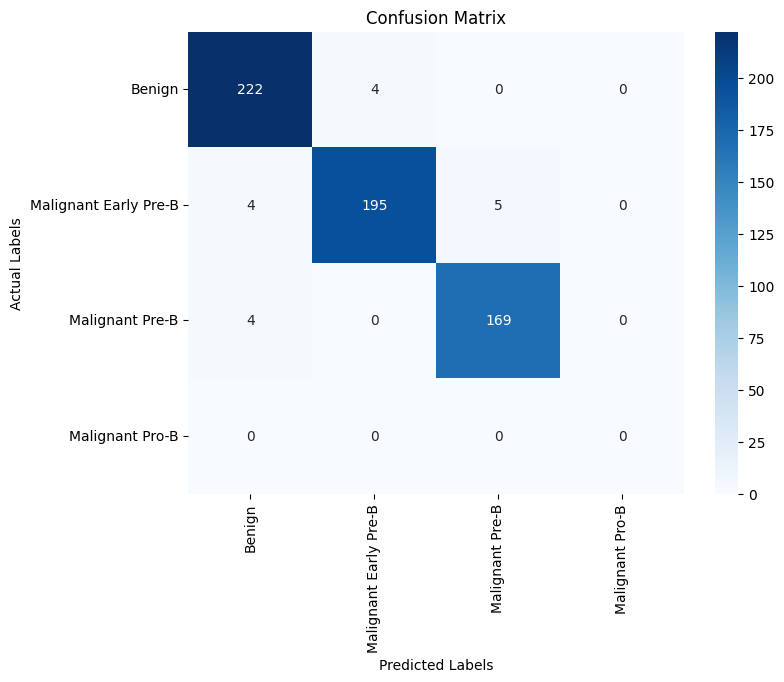

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the confusion matrix values
confusion_matrix = np.array([
    [222, 4, 0, 0],
    [4, 195, 5, 0],
    [4, 0, 169, 0],
    [0, 0, 0, 0]
])

# Define the labels for the axes
labels = ["Benign", "Malignant Early Pre-B", "Malignant Pre-B", "Malignant Pro-B"]

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

# Add labels, title, and axis names
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix")
plt.show()


Classification Report:

                       precision    recall  f1-score   support

               Benign       0.78      0.97      0.86        33
Malignant Early Pre-B       0.93      0.86      0.90        50
      Malignant Pre-B       0.99      0.98      0.98        86
      Malignant Pro-B       1.00      0.96      0.98        69

             accuracy                           0.95       238
            macro avg       0.93      0.94      0.93       238
         weighted avg       0.95      0.95      0.95       238



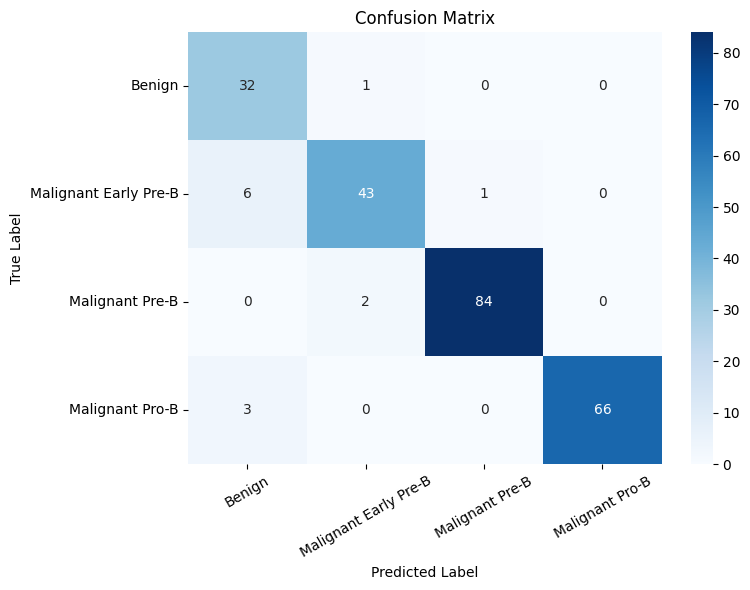

In [13]:
import numpy as np
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Define class labels
labels = ["Benign", "Malignant Early Pre-B", "Malignant Pre-B", "Malignant Pro-B"]

# Confusion matrix
conf_matrix = np.array([
    [32, 1, 0, 0],
    [6, 43, 1, 0],
    [0, 2, 84, 0],
    [3, 0, 0, 66]
])

# Convert confusion matrix to y_true and y_pred
y_true = []
y_pred = []

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        y_true.extend([i] * conf_matrix[i][j])
        y_pred.extend([j] * conf_matrix[i][j])

# Print classification report
print("Classification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3],
    target_names=labels,
    zero_division=0
))

# Optional: Confusion matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
history_plot(epochs,history)

In [ ]:
evaluate_model(model3, test_generator)

Test Loss = 0.40209174156188965
Test Accuracy = 0.8662551641464233


In [ ]:
model3.save("VGG16.keras")

In [ ]:
from IPython.display import FileLink
FileLink(r'VGG16.keras')

/content/VGG16.keras

Conclusion

In [ ]:
models = [model1, model2, model3]
loss = []
accuracy = []
for model in models:
    results = model.evaluate(test_generator, verbose = 0)
    loss.append(results[0])
    accuracy.append(results[1])

In [ ]:
name_models = ["CNN (Custom)", "LeukoScan", "VGG16"]
df_loss_acc = pd.DataFrame(data = {"Name_Models" : name_models,
                                  "Loss" : loss,
                                  "Accuracy" : accuracy})

fig = px.bar(data_frame = df_loss_acc, x = "Name_Models", y = ["Accuracy", "Loss"],
            barmode = "group",
            text_auto = ".3f")
fig.show()